# Градиентный бустинг

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from pathlib import Path
import warnings
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from research_utils.learning import grid_search, iteration_learning_score, get_top_n_info
from research_utils.plot import create_panel, plot_learning_curve, plot_complexity_and_accuracy
from predictors.serialization import save_model
from predictors.feature_selection import ModelFeatureSelector
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

save = partial(save_model, models_dir)
train = pd.read_parquet("../data/processed/train.parquet")

## Подготовка данных
Для модели Gradient Boosting нет необходимости в предобработке данных. Но для упрощения вычислений можно убрать признаки `used`, поскольку модель сможет самостоятельно определить использование по интенсивности

In [3]:
features = [
    'text__symbols_length',
    'text__sentences_count',
    'text__long_sentences_proportion',
    'text__unpopular_words_proportion',
    'text__rare_words_proportion',
    'text__type_token_ratio',
    'text__normalized_shannon_entropy',
    'text__mean_words_length',
    'text__long_words_proportion',
    'text__lexicon_size',
    'text__lexical_diversity_per_sentence',
    'entities__mean_usage_QUOTE',
    'entities__mean_usage_NUMBER',
    'entities__breadth_of_use_entities',
    'pos__index_of_formality',
    'pos__pair_of_adv_per_sentence',
    'pos__mean_usage_NOUN',
    'pos__mean_usage_PRON',
    'pos__mean_usage_ADV',
    'pos__mean_usage_ADP',
    'pos__mean_usage_ADJ',
    'pos__mean_usage_SCONJ',
    'pos__mean_usage_AUX',
    'pos__mean_usage_CCONJ',
    'pos__mean_usage_VERB',
    'pos__mean_usage_PROPN',
    'pos__mean_usage_DET',
    'pos__mean_usage_PART',
    'pos__ADJPOS_NOUN',
    'pos__PROPN_PUNCT',
    'pos__PUNCT_SCONJ',
    'pos__ADP_ADJPOS',
    'pos__ADP_PRON',
    'pos__PUNCT_ADV',
    'pos__PUNCT_PRON',
    'pos__ADJPOS_PUNCT',
    'pos__PUNCT_CCONJ',
    'pos__index_of_formality_heylinger',
    'punct__breadth_of_use_puncts',
    'punct__mean_usage_colon',
    'punct__mean_usage_dot',
    'punct__mean_usage_question',
    'punct__mean_usage_openparen',
    'punct__mean_usage_comma',
    'punct__mean_usage_closeparen',
    'punct__mean_usage_hyphen',
    'entities__mean_usage_PUNCEM',
    'pos__mean_usage_NUM',
    'punct__mean_usage_exclamation',
    'entities__mean_usage_ADDRESS',
    'entities__mean_usage_MEAS_is_typical',
    'entities__mean_usage_ENUM_is_typical',
    'entities__mean_usage_FOREIGN_is_typical',
    'pos__breadth_of_use_pos_is_typical',
    'pos__index_of_formality_tuldava_is_typical',
    'entities__mean_usage_SMILE_is_typical',
    'entities__mean_usage_DATE_is_typical'
]

criterions = [ 'friedman_mse', 'squared_error']
max_depths = np.arange(5, 10)
max_features = np.arange(5, 10)
n_estimators = [25, 50, 100, 150, 200]

pipeline_params = {
    'model__criterion': criterions,
    'model__max_depth': max_depths,
    'model__n_estimators': n_estimators,
    'model__max_features': max_features,
    "model__random_state": [ 42 ]
}

def create_gbm_pipeline(model_params=None):
    if not model_params:
        model_params = {}
    
    return Pipeline([
        ('get_features', ModelFeatureSelector(features)),
        ('model', GradientBoostingClassifier(**model_params)),
    ])

## Независимые модели

### Классификатор пола

In [4]:
gender_pipeline = create_gbm_pipeline()

gender_gs = grid_search(gender_pipeline, pipeline_params, train, train['gender'])

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


In [5]:
gender_gs.best_params_, gender_gs.best_score_

({'model__criterion': 'squared_error',
  'model__max_depth': np.int64(6),
  'model__max_features': np.int64(9),
  'model__n_estimators': 100,
  'model__random_state': 42},
 np.float64(0.6795844155844155))

In [6]:
gender_top_5_info = get_top_n_info(gender_gs, n=5)
gender_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_depth,param_model__max_features,param_model__n_estimators,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
172,2.696974,0.023705,0.008859,0.000670,squared_error,6,9,100,42,"{'model__criterion': 'squared_error', 'model__...",0.675844,0.683117,0.669610,0.679481,0.689870,0.679584,0.006808,1
59,5.273745,0.176401,0.017928,0.000887,friedman_mse,7,6,200,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.679481,0.693506,0.669091,0.681558,0.673766,0.679481,0.008266,2
188,4.011828,0.050224,0.012997,0.000368,squared_error,7,7,150,42,"{'model__criterion': 'squared_error', 'model__...",0.676364,0.685714,0.669091,0.684675,0.681039,0.679377,0.006097,3
187,2.670143,0.094473,0.010064,0.000694,squared_error,7,7,100,42,"{'model__criterion': 'squared_error', 'model__...",0.670649,0.681558,0.671688,0.684675,0.681039,0.677922,0.005662,4
2,1.430658,0.033308,0.008606,0.000261,friedman_mse,5,5,100,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.674286,0.670649,0.676364,0.686234,0.681558,0.677818,0.005492,5


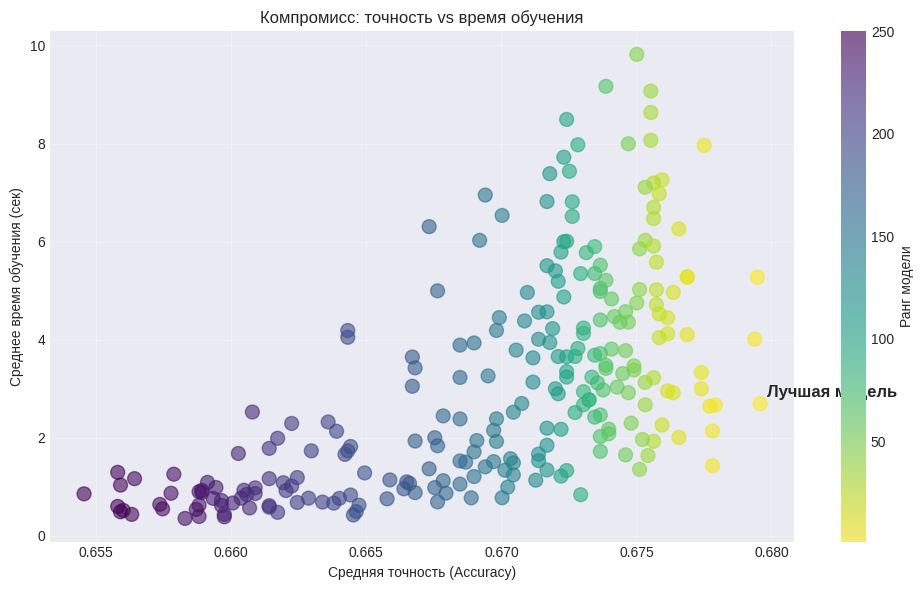

In [20]:
plot_complexity_and_accuracy(gender_gs)

In [21]:
best_model_params = { 
    'model__criterion': 'squared_error',
    'model__max_depth': 6,
    'model__max_features': 9,
    'model__n_estimators': 100,
    'model__random_state': 42
}
best_model = create_gbm_pipeline()
best_model.set_params(**best_model_params)
best_model_iter_learning_score = iteration_learning_score(best_model, train, train['gender'])

In [22]:
simple_model = create_gbm_pipeline({
    'criterion': 'squared_error',
    'max_depth': 5,
    'max_features': 5,
    'n_estimators': 25,
    'random_state': 42})
simple_model_iter_learning_score = iteration_learning_score(simple_model, train, train['gender'])

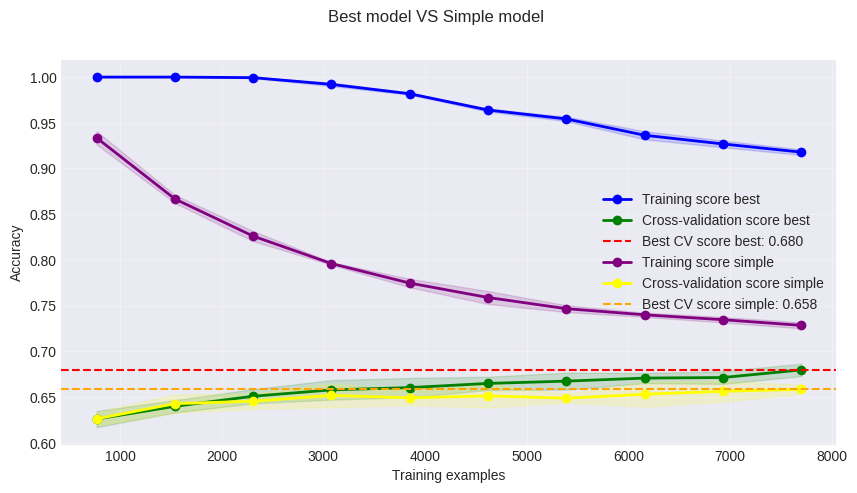

In [23]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*simple_model_iter_learning_score, ax=axes.flat[0], name='simple', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Simple model")
plt.show()

Аналогичная ситуация:
- Сигнал из данных определяется
- Но сигнал слабый, поскольку признаки недостаточно информативны
- Достигнут информационный предел признаков

По графику обучения заметно, что уже на первых 10% данных модель запоминает даннык и показывает результат, превосходящий случайное гадание на 12% относительно 53%. Причем, как в сложной конфигурации, так и в простой.

Дальнейшее увеличение кол-ва наблюдений в сложной конфигурации приводит к незначительному повышению показаний точности на валидационной выборке. Лучший показатель - 68%. Простая конфигурация отстает всего на 2%, как и в модели случайного леса

In [24]:
best_model.fit(train, train['gender'])
save(
    best_model, 
    "gbm_gender_best", 
    best_model_params, 
    { "val": best_model_iter_learning_score[2].tolist(), "train": best_model_iter_learning_score[1].tolist() }
)

### Классификатор возраста

In [7]:
age_pipeline = create_gbm_pipeline()

age_gs = grid_search(age_pipeline, pipeline_params, train, train['age'])

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


In [8]:
age_gs.best_params_, age_gs.best_score_

({'model__criterion': 'friedman_mse',
  'model__max_depth': np.int64(5),
  'model__max_features': np.int64(7),
  'model__n_estimators': 200,
  'model__random_state': 42},
 np.float64(0.6276363636363637))

In [9]:
age_top_5_info = get_top_n_info(age_gs, n=5)
age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_depth,param_model__max_features,param_model__n_estimators,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
14,3.421233,0.014242,0.011072,0.000269,friedman_mse,5,7,200,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.614026,0.627532,0.622857,0.629091,0.644675,0.627636,0.010005,1
243,6.930948,0.098379,0.019125,0.000796,squared_error,9,8,150,42,"{'model__criterion': 'squared_error', 'model__...",0.624416,0.619740,0.625455,0.624416,0.642078,0.627221,0.007688,2
244,9.039108,0.063252,0.023248,0.000470,squared_error,9,8,200,42,"{'model__criterion': 'squared_error', 'model__...",0.615584,0.618701,0.621818,0.632727,0.644156,0.626597,0.010510,3
13,2.601680,0.069276,0.009353,0.000429,friedman_mse,5,7,150,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.610909,0.629091,0.618182,0.628052,0.641558,0.625558,0.010428,4
137,1.766419,0.044671,0.007677,0.000350,squared_error,5,7,100,42,"{'model__criterion': 'squared_error', 'model__...",0.616623,0.627532,0.622857,0.631688,0.627013,0.625143,0.005096,5


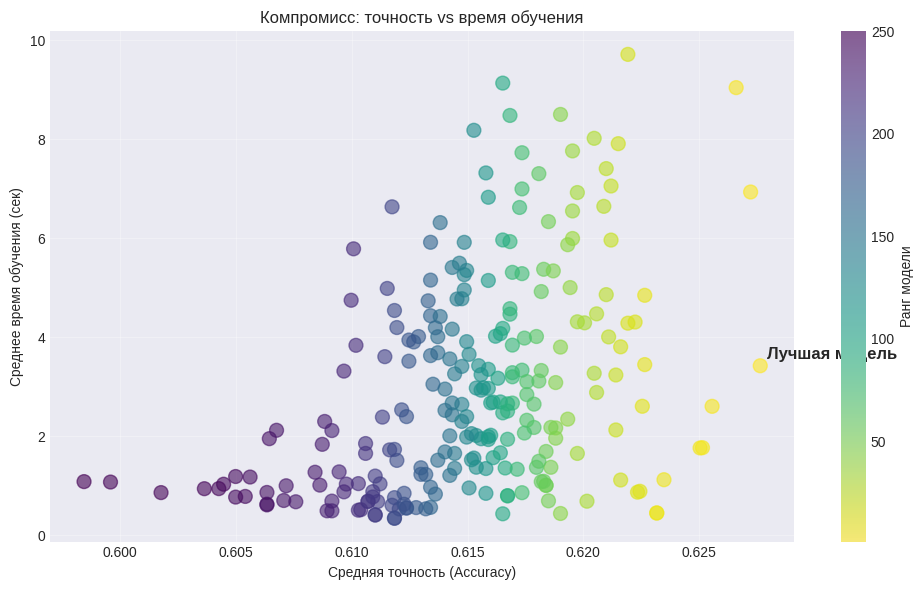

In [25]:
plot_complexity_and_accuracy(age_gs)

In [26]:
age_best_model_params = { 
    'model__criterion': 'friedman_mse',
    'model__max_depth': 5,
    'model__max_features': 7,
    'model__n_estimators': 200,
    'model__random_state': 42
}
age_best_model = create_gbm_pipeline()
age_best_model.set_params(**age_best_model_params)
age_best_model_iter_learning_score = iteration_learning_score(age_best_model, train, train['age'])

In [27]:
age_simple_model = create_gbm_pipeline({
    'criterion': 'friedman_mse',
    'max_depth': 5,
    'max_features': 5,
    'n_estimators': 25,
    'random_state': 42})
age_simple_model_iter_learning_score = iteration_learning_score(age_simple_model, train, train['age'])

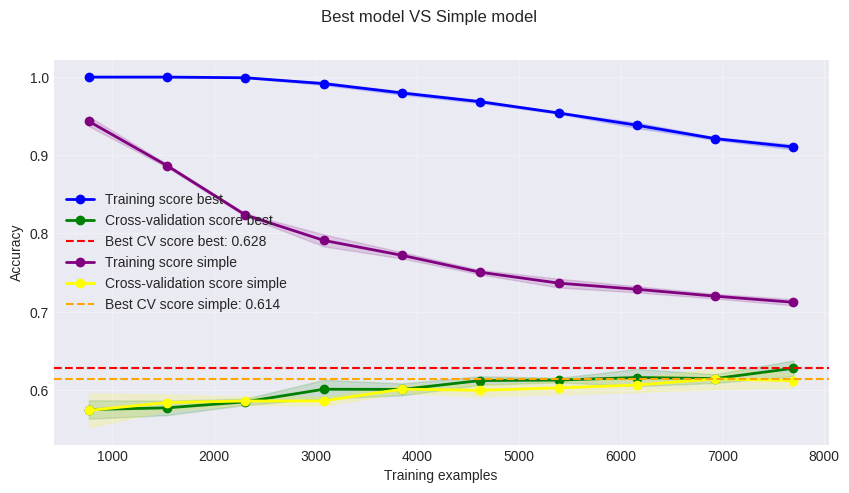

In [28]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*age_simple_model_iter_learning_score, ax=axes.flat[0], name='simple', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Simple model")
plt.show()

Аналогичная ситуация с классификацией возрастной группы. Сложная конфигурация всего на 1% лучше простой на валидационной выборке.

In [29]:
age_best_model.fit(train, train['age'])
save(
    age_best_model, 
    "gbm_age_best", 
    age_best_model_params, 
    { "val": age_best_model_iter_learning_score[2].tolist(), "train": age_best_model_iter_learning_score[1].tolist() }
)

## Каскадный подход

Прогнозирование пола показывает более высокий показатель точности, по сравнению с прогнозирование возрастной группы. По этой причине сначала будет прогнозироваться пол, а затем в рамках пола - возраст

### Прогнозирование возраста мужчин

In [10]:
man_age_pipeline = create_gbm_pipeline()

men_train = train[train['gender'] == 1]

men_age_gs = grid_search(man_age_pipeline, pipeline_params, men_train, men_train['age'])

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


In [11]:
men_age_gs.best_params_, men_age_gs.best_score_

({'model__criterion': 'squared_error',
  'model__max_depth': np.int64(8),
  'model__max_features': np.int64(9),
  'model__n_estimators': 200,
  'model__random_state': 42},
 np.float64(0.6398979880465647))

In [12]:
men_age_top_5_info = get_top_n_info(men_age_gs, n=5)
men_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_depth,param_model__max_features,param_model__n_estimators,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
224,5.193326,0.065764,0.013768,0.000437,squared_error,8,9,200,42,"{'model__criterion': 'squared_error', 'model__...",0.646552,0.650383,0.635057,0.644295,0.623202,0.639898,0.009754,1
104,4.929229,0.111662,0.016278,0.000416,friedman_mse,9,5,200,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.625479,0.642720,0.634100,0.651007,0.641419,0.638945,0.008610,2
229,4.970153,0.144740,0.016316,0.000881,squared_error,9,5,200,42,"{'model__criterion': 'squared_error', 'model__...",0.621648,0.654215,0.648467,0.637584,0.629914,0.638365,0.011872,3
209,4.005249,0.038661,0.013680,0.000321,squared_error,8,6,200,42,"{'model__criterion': 'squared_error', 'model__...",0.643678,0.640805,0.632184,0.648130,0.625120,0.637983,0.008276,4
234,5.368593,0.127381,0.016410,0.000563,squared_error,9,6,200,42,"{'model__criterion': 'squared_error', 'model__...",0.636015,0.633142,0.647510,0.642378,0.628955,0.637600,0.006605,5


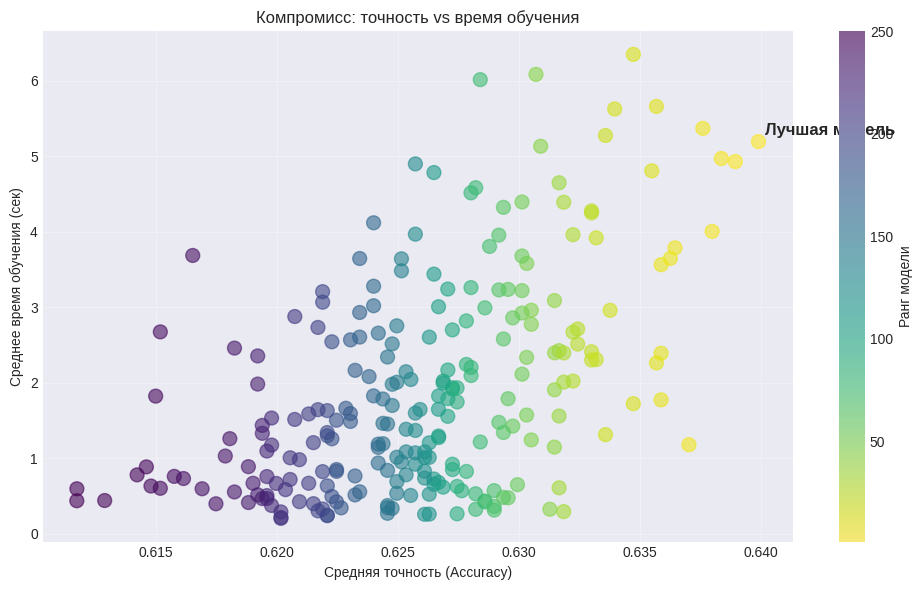

In [44]:
plot_complexity_and_accuracy(men_age_gs)

In [30]:
men_age_best_model_params = { 
    'model__criterion': 'squared_error',
    'model__max_depth': 8,
    'model__max_features': 9,
    'model__n_estimators': 200,
    'model__random_state': 42
}
men_age_best_model = create_gbm_pipeline()
men_age_best_model.set_params(**men_age_best_model_params)
men_age_best_model_iter_learning_score = iteration_learning_score(men_age_best_model, men_train, men_train['age'])

In [31]:
men_age_simple_model = create_gbm_pipeline({
    'criterion': 'squared_error',
    'max_depth': 5,
    'max_features': 5,
    'n_estimators': 25,
    'random_state': 42})
men_age_simple_model_iter_learning_score = iteration_learning_score(men_age_simple_model, men_train, men_train['age'])

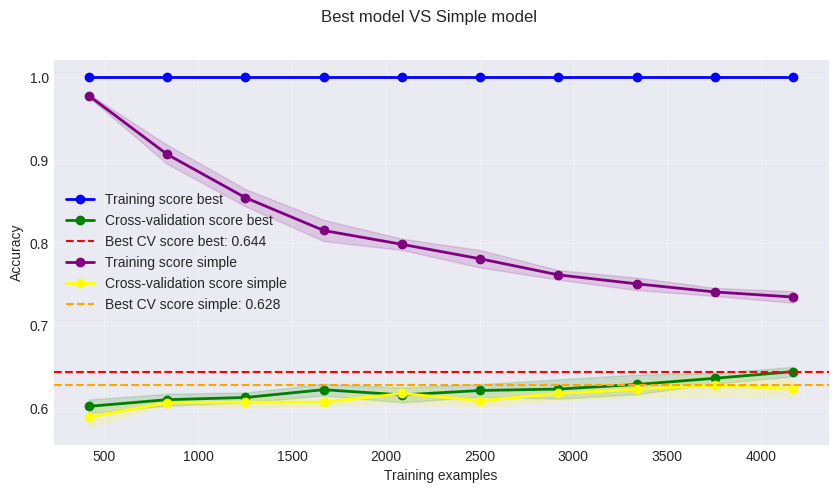

In [32]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*men_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*men_age_simple_model_iter_learning_score, ax=axes.flat[0], name='simple', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Simple model")
plt.show()

Лучшая конфигурация модели запомнить - весь датасет. И это запоминание дает 1.5% прироста точности на валидационной выборке

Определение возраста в мужской подвыборке так-же повысило точность на 1.5%

In [33]:
men_age_best_model.fit(men_train, men_train['age'])
save(
    men_age_best_model, 
    "gbm_men_age_best", 
    men_age_best_model_params, 
    { "val": men_age_best_model_iter_learning_score[2].tolist(), "train": men_age_best_model_iter_learning_score[1].tolist() }
)

### Прогнозирование возраста женщин

In [13]:
woman_age_pipeline = create_gbm_pipeline()

women_train = train[train['gender'] == 0]

women_age_gs = grid_search(woman_age_pipeline, pipeline_params, women_train, women_train['age'])

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


In [14]:
women_age_gs.best_params_, women_age_gs.best_score_

({'model__criterion': 'squared_error',
  'model__max_depth': np.int64(8),
  'model__max_features': np.int64(5),
  'model__n_estimators': 200,
  'model__random_state': 42},
 np.float64(0.6796031617338573))

In [15]:
women_age_top_5_info = get_top_n_info(women_age_gs, n=5)
women_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_depth,param_model__max_features,param_model__n_estimators,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
204,3.295688,0.083214,0.012702,0.000649,squared_error,8,5,200,42,"{'model__criterion': 'squared_error', 'model__...",0.671202,0.676871,0.664018,0.706016,0.679909,0.679603,0.014274,1
79,3.239167,0.069193,0.012209,0.000279,friedman_mse,8,5,200,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.672336,0.670068,0.665153,0.690125,0.690125,0.677561,0.010518,2
154,1.870529,0.027301,0.008845,0.000127,squared_error,6,5,200,42,"{'model__criterion': 'squared_error', 'model__...",0.656463,0.660998,0.690125,0.692395,0.686720,0.677340,0.015369,3
89,3.895714,0.144629,0.012244,0.000757,friedman_mse,8,7,200,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.680272,0.657596,0.674234,0.688990,0.685585,0.677335,0.011061,4
94,4.244934,0.115954,0.012412,0.000579,friedman_mse,8,8,200,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.672336,0.659864,0.686720,0.691260,0.674234,0.676883,0.011143,5


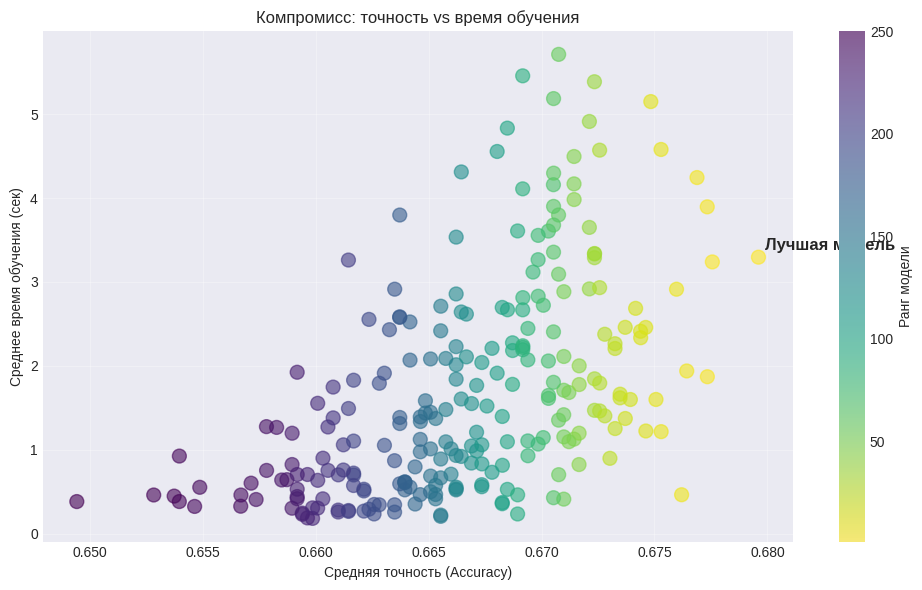

In [43]:
plot_complexity_and_accuracy(women_age_gs)

In [34]:
women_age_best_model_params = { 
    'model__criterion': 'squared_error',
    'model__max_depth': 8,
    'model__max_features': 5,
    'model__n_estimators': 200,
    'model__random_state': 42
}
women_age_best_model = create_gbm_pipeline()
women_age_best_model.set_params(**women_age_best_model_params)
women_age_best_model_iter_learning_score = iteration_learning_score(women_age_best_model, women_train, women_train['age'])

In [35]:
women_age_simple_model = create_gbm_pipeline({
    'criterion': 'squared_error',
    'max_depth': 5,
    'max_features': 5,
    'n_estimators': 25,
    'random_state': 42})
women_age_simple_model_iter_learning_score = iteration_learning_score(women_age_simple_model, women_train, women_train['age'])

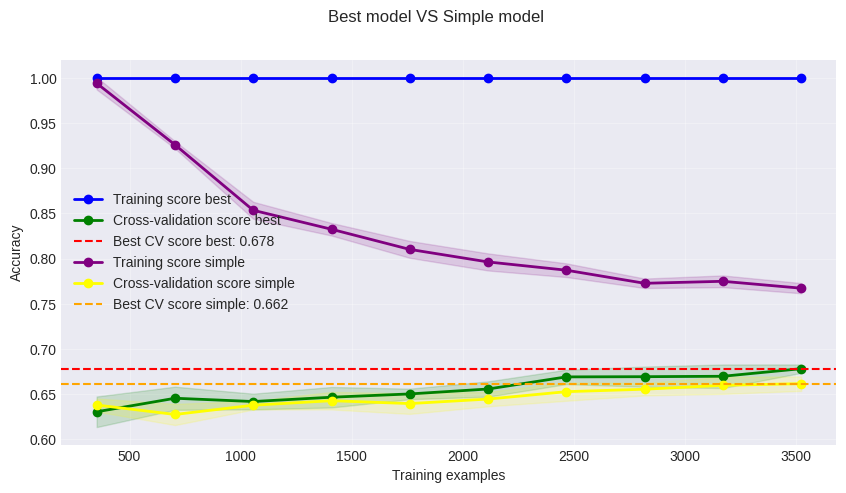

In [36]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*women_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*women_age_simple_model_iter_learning_score, ax=axes.flat[0], name='simple', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Simple model")
plt.show()

Разница сложной и простой конфигурации в женской подвыборке так-же составляет около 1.5%.

Использование каскадного подхода позволило слегка улучшить качество прогнозирования с 63% до 64%-68%. Каждая модель стала лучше разбираться в рамках своего пола

In [37]:
women_age_best_model.fit(women_train, women_train['age'])
save(
    women_age_best_model, 
    "gbm_women_age_best", 
    women_age_best_model_params, 
    { "val": women_age_best_model_iter_learning_score[2].tolist(), "train": women_age_best_model_iter_learning_score[1].tolist() }
)

## Плоский подход

In [16]:
flat_y_train = train['gender'] * 2 + train['age']

In [17]:
flat_pipeline = create_gbm_pipeline()

flat_gs = grid_search(flat_pipeline, pipeline_params, train, flat_y_train)

Fitting 5 folds for each of 250 candidates, totalling 1250 fits


In [18]:
flat_gs.best_params_, flat_gs.best_score_

({'model__criterion': 'squared_error',
  'model__max_depth': np.int64(9),
  'model__max_features': np.int64(9),
  'model__n_estimators': 200,
  'model__random_state': 42},
 np.float64(0.46171428571428574))

In [19]:
flat_top_5_info = get_top_n_info(flat_gs, n=5)
flat_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__criterion,param_model__max_depth,param_model__max_features,param_model__n_estimators,param_model__random_state,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
249,33.639691,2.158511,0.073472,0.001305,squared_error,9,9,200,42,"{'model__criterion': 'squared_error', 'model__...",0.452987,0.454545,0.455065,0.472727,0.473247,0.461714,0.009231,1
119,39.733142,0.303952,0.089312,0.003524,friedman_mse,9,8,200,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.456623,0.460779,0.445714,0.469610,0.472208,0.460987,0.009514,2
108,25.729388,0.233591,0.067904,0.000644,friedman_mse,9,6,150,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.456623,0.455584,0.456104,0.464935,0.469091,0.460468,0.005513,3
69,25.250458,0.439345,0.059399,0.001847,friedman_mse,7,8,200,42,"{'model__criterion': 'friedman_mse', 'model__m...",0.453506,0.452468,0.456104,0.473247,0.465974,0.460260,0.008061,4
239,37.516714,1.219754,0.092037,0.003252,squared_error,9,7,200,42,"{'model__criterion': 'squared_error', 'model__...",0.462338,0.451948,0.454545,0.468052,0.464416,0.460260,0.006067,5


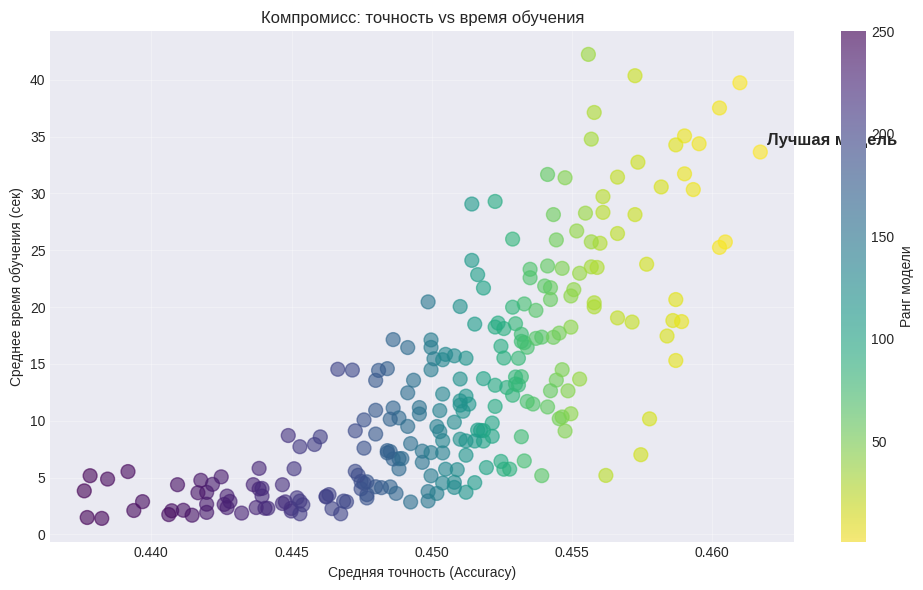

In [39]:
plot_complexity_and_accuracy(flat_gs)

In [38]:
flat_best_model_params = { 
    'model__criterion': 'squared_error',
    'model__max_depth': 9,
    'model__max_features': 9,
    'model__n_estimators': 200,
    'model__random_state': 42
}
flat_best_model = create_gbm_pipeline()
flat_best_model.set_params(**flat_best_model_params)
flat_best_model_iter_learning_score = iteration_learning_score(flat_best_model, train, flat_y_train)

In [40]:
flat_simple_model = create_gbm_pipeline({
    'criterion': 'squared_error',
    'max_depth': 5,
    'max_features': 5,
    'n_estimators': 25,
    'random_state': 42})
flat_simple_model_iter_learning_score = iteration_learning_score(flat_simple_model, train, flat_y_train)

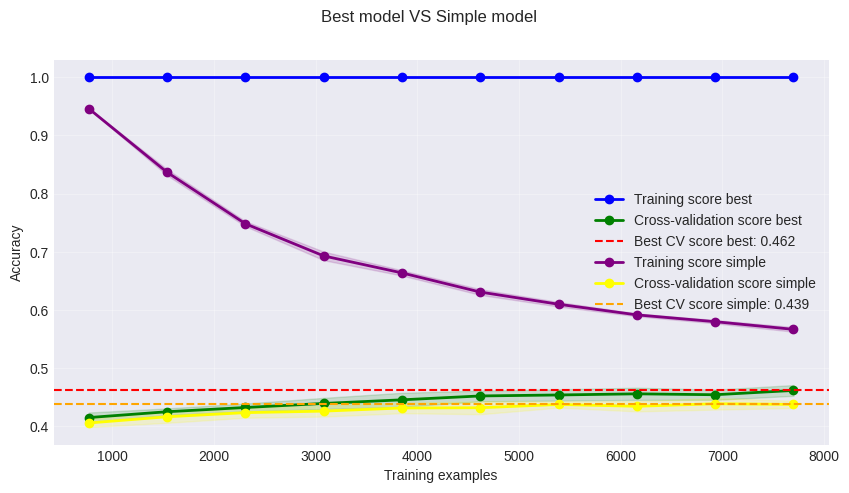

In [41]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*flat_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*flat_simple_model_iter_learning_score, ax=axes.flat[0], name='simple', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Simple model")
plt.show()

Разница сложной и простой конфигурации составляет около 2%

Точность каскадного подхода приблизительно составит `0.68 * 0.644 = 0.438`. Плоский подход превосходит эту приблизительную точность на 2% процента.

In [42]:
flat_best_model.fit(train, flat_y_train)
save(
    flat_best_model, 
    "gbm_flat_best", 
    flat_best_model_params, 
    { "val": flat_best_model_iter_learning_score[2].tolist(), "train": flat_best_model_iter_learning_score[1].tolist() }
)